In [1]:
!pip install pandas numpy matplotlib seaborn scipy statsmodels lifelines gseapy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 634.7/634.7 kB 34.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 8.1 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=22059474e9f77f9bb188588d36b3406815091c544d30bb746c684049241b3f8c
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


In [2]:
from google.colab import drive
drive.mount('/content/drive')

expr = pd.read_csv("/content/drive/MyDrive/TCGA_LIHC_gene_expression_counts.csv", index_col=0)
clinical = pd.read_csv("/content/drive/MyDrive/TCGA_LIHC_clinical_metadata.csv")

expr.head()

Mounted at /content/drive


,TCGA-DD-AAW1-01A,TCGA-ED-A66Y-01A,TCGA-DD-AAVX-01A,TCGA-DD-A115-01A,TCGA-DD-AACN-01A,TCGA-DD-A4NJ-01A,TCGA-DD-AACS-01A,TCGA-DD-A118-11A,TCGA-DD-A118-01A,TCGA-DD-A1EG-11A,...,TCGA-CC-A5UE-01A,TCGA-5R-AA1D-01A,TCGA-DD-A4NG-01A,TCGA-2Y-A9HB-01A,TCGA-FV-A3R2-11A,TCGA-WQ-AB4B-01A,TCGA-ED-A7PZ-01A,TCGA-CC-A9FS-01A,TCGA-CC-A5UC-01A,TCGA-FV-A2QQ-01A
Gene_ID,,,,,,,,,,,,,,,,,,,,,
N_unmapped,1409695,1123687,3802960,620612,2012195,862474,571615,480977,1765755,11334563,...,2794822,1657263,1681634,1801511,2199231,790040,2613864,2990903,823424,1269206
N_multimapping,5476674,4892853,3927848,3883296,4317766,2942286,2202027,3535373,6702531,7932313,...,4628912,5761745,9025028,4578856,5043962,4475521,6983966,6283106,3556357,5146946
N_noFeature,1868900,2137163,638897,921402,1766378,2279278,1122016,644756,1504323,1071569,...,1300410,1014740,1597601,1477662,1046627,710572,1411422,1851987,728902,1126905
N_ambiguous,6049905,7157490,3725389,4739359,6515230,3613353,3590402,3713749,9145105,5489589,...,6022249,4715131,5535043,6511655,5601533,4350240,7978325,6011036,4384099,6681952
ENSG00000000003.15,16122,2349,3815,2332,3015,3382,4530,3008,5995,3729,...,13833,3844,7045,2372,3034,3189,6414,32888,5147,4885


DATA CLEANING & LOG TRANSFORMATION

In [3]:
expr = expr[~expr.index.str.startswith("N_")]

print(expr.shape)

(60660, 424)


In [4]:
expr.index = expr.index.str.split(".").str[0]

expr.head()

,TCGA-DD-AAW1-01A,TCGA-ED-A66Y-01A,TCGA-DD-AAVX-01A,TCGA-DD-A115-01A,TCGA-DD-AACN-01A,TCGA-DD-A4NJ-01A,TCGA-DD-AACS-01A,TCGA-DD-A118-11A,TCGA-DD-A118-01A,TCGA-DD-A1EG-11A,...,TCGA-CC-A5UE-01A,TCGA-5R-AA1D-01A,TCGA-DD-A4NG-01A,TCGA-2Y-A9HB-01A,TCGA-FV-A3R2-11A,TCGA-WQ-AB4B-01A,TCGA-ED-A7PZ-01A,TCGA-CC-A9FS-01A,TCGA-CC-A5UC-01A,TCGA-FV-A2QQ-01A
Gene_ID,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003,16122,2349,3815,2332,3015,3382,4530,3008,5995,3729,...,13833,3844,7045,2372,3034,3189,6414,32888,5147,4885
ENSG00000000005,1,0,5,2,0,1,0,1,0,14,...,1,2,4,1,11,5,0,13,0,2
ENSG00000000419,1148,1084,554,795,1124,1086,865,777,1728,954,...,1426,994,1890,1264,980,703,1388,1249,1637,1110
ENSG00000000457,775,1173,308,310,943,415,537,279,673,327,...,700,341,686,791,289,216,347,472,498,462
ENSG00000000460,1489,285,221,103,206,246,309,82,233,56,...,379,87,298,198,55,42,207,128,280,170


In [5]:
!wget -O gencode.v38.annotation.gtf.gz \
https://ftp.ebi.ac.uk/pub/databases/gencode/Gencode_human/release_38/gencode.v38.annotation.gtf.gz

--2026-06-18 06:22:06--  https://ftp.ebi.ac.uk/pub/databases/gencode/Gencode_human/release_38/gencode.v38.annotation.gtf.gz
Resolving ftp.ebi.ac.uk (ftp.ebi.ac.uk)... 193.62.193.165
Connecting to ftp.ebi.ac.uk (ftp.ebi.ac.uk)|193.62.193.165|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 46556621 (44M) [application/x-gzip]
Saving to: ‘gencode.v38.annotation.gtf.gz’

gencode.v38.annotat 100%[===================>]  44.40M  2.82MB/s    in 23s     

2026-06-18 06:22:30 (1.92 MB/s) - ‘gencode.v38.annotation.gtf.gz’ saved [46556621/46556621]



In [6]:
import gzip
import re

mapping = {}

with gzip.open("gencode.v38.annotation.gtf.gz", "rt") as f:

    for line in f:

        if line.startswith("#"):
            continue

        fields = line.strip().split("\t")

        if fields[2] != "gene":
            continue

        attributes = fields[8]

        gene_id = re.search(
            'gene_id "([^"]+)"',
            attributes
        ).group(1)

        gene_name = re.search(
            'gene_name "([^"]+)"',
            attributes
        ).group(1)

        mapping[gene_id.split(".")[0]] = gene_name

print("Mapped genes:", len(mapping))

Mapped genes: 60605


In [7]:
expr["GeneSymbol"] = expr.index.map(mapping)

expr = expr.dropna(subset=["GeneSymbol"])

# Set 'GeneSymbol' as the new index before grouping
expr = expr.set_index("GeneSymbol")

# Now, group by the new index (GeneSymbol) and sum counts for duplicate gene symbols
expr = expr.groupby(level=0).sum()

print(expr.shape)

(59341, 424)


In [8]:
expr_log = np.log2(expr + 1)

In [28]:
immune_check = [
    "CD8A",
    "CD3D",
    "CD68",
    "MS4A1",
    "NCAM1",
    "CD163"
]

for gene in immune_check:
    print(gene, gene in expr_log.index)

CD8A True
CD3D True
CD68 True
MS4A1 True
NCAM1 True
CD163 True


In [41]:
import gseapy as gp
import pandas as pd

print("[-] Restructuring gene dictionary for GSEApy compatibility...")

# Ensure all dictionary values are explicit lists of strings for the API wrapper
gene_sets_formatted = {cell_type: list(genes) for cell_type, genes in immune_genes.items()}

# Convert gene symbols in expr index to uppercase for compatibility with gseapy
# Many gene sets (like those from Enrichr) use all uppercase gene symbols
expr_upper_index = expr.copy()
expr_upper_index.index = expr_upper_index.index.str.upper()

print("[-] Executing single-sample Gene Set Enrichment Analysis (ssGSEA)...")

# Run ssGSEA
ssgsea_run = gp.ssgsea(
    data=expr_upper_index, # Use the DataFrame with uppercase gene symbols
    gene_sets=gene_sets_formatted,
    outdir=None,                 # Retain output in active memory; do not dump files to disk
    sample_norm_method="rank",   # Normalize utilizing relative intra-sample ranking profiles
    permutation_num=0,           # Normalized enrichment scores (NES) only; omitting null p-values
    min_size=1                   # Allow gene sets with as few as 1 gene
)

# Extract Normalized Enrichment Scores (NES) and form the immune_scores DataFrame
# This creates a DataFrame with samples as index and gene sets as columns, containing NES values
immune_scores = ssgsea_run.res2d.pivot_table(index='Name', columns='Term', values='NES')

print(f"[+] ssGSEA calculations finalized successfully!")
print(f"[+] Computed feature dimension matrix: {immune_scores.shape}")

[-] Restructuring gene dictionary for GSEApy compatibility...
[-] Executing single-sample Gene Set Enrichment Analysis (ssGSEA)...
[+] ssGSEA calculations finalized successfully!
[+] Computed feature dimension matrix: (424, 5)


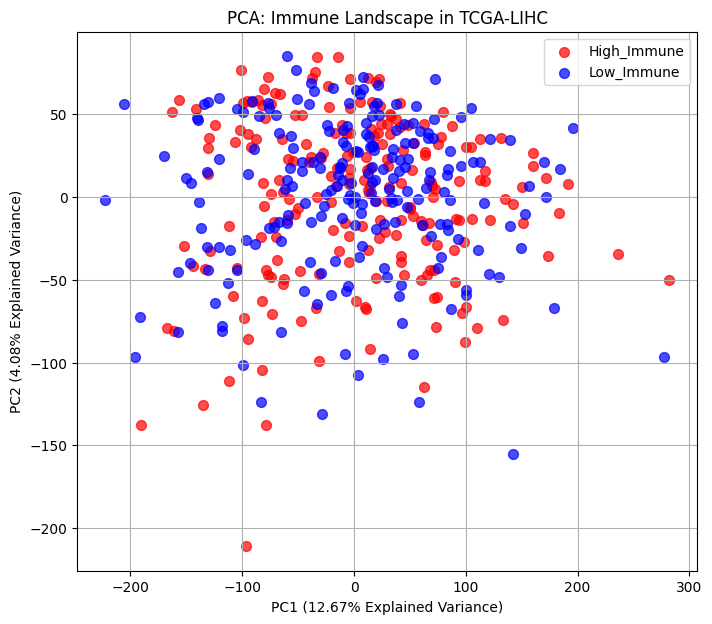

In [51]:
X = StandardScaler().fit_transform(expr_log.T)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(X)

# Define Risk_Group based on median split of CD8_T_cells
median_cd8 = immune_scores["CD8_T_cells"].median()
immune_scores["Risk_Group"] = immune_scores["CD8_T_cells"].apply(
    lambda x: "High_Immune" if x >= median_cd8 else "Low_Immune"
)

# Get explained variance for axis labels
explained_variance_ratio = pca.explained_variance_ratio_ * 100

plt.figure(figsize=(8,7))

# Create a mapping for colors and labels
color_map = {"High_Immune":"red", "Low_Immune":"blue"}

# Plot each group separately to get a legend
for group_name, color in color_map.items():
    # Select data points belonging to the current group
    mask = immune_scores["Risk_Group"] == group_name
    plt.scatter(
        pca_result[mask, 0],
        pca_result[mask, 1],
        c=color,
        label=group_name,
        s=50, # Increased marker size
        alpha=0.7 # Added transparency
    )

plt.title("PCA: Immune Landscape in TCGA-LIHC")
plt.xlabel(f"PC1 ({explained_variance_ratio[0]:.2f}% Explained Variance)")
plt.ylabel(f"PC2 ({explained_variance_ratio[1]:.2f}% Explained Variance)")
plt.legend() # Display the legend
plt.grid(True) # Add a grid for better readability
plt.savefig("pca_immune_landscape.png") # Save the plot to a file

plt.show()

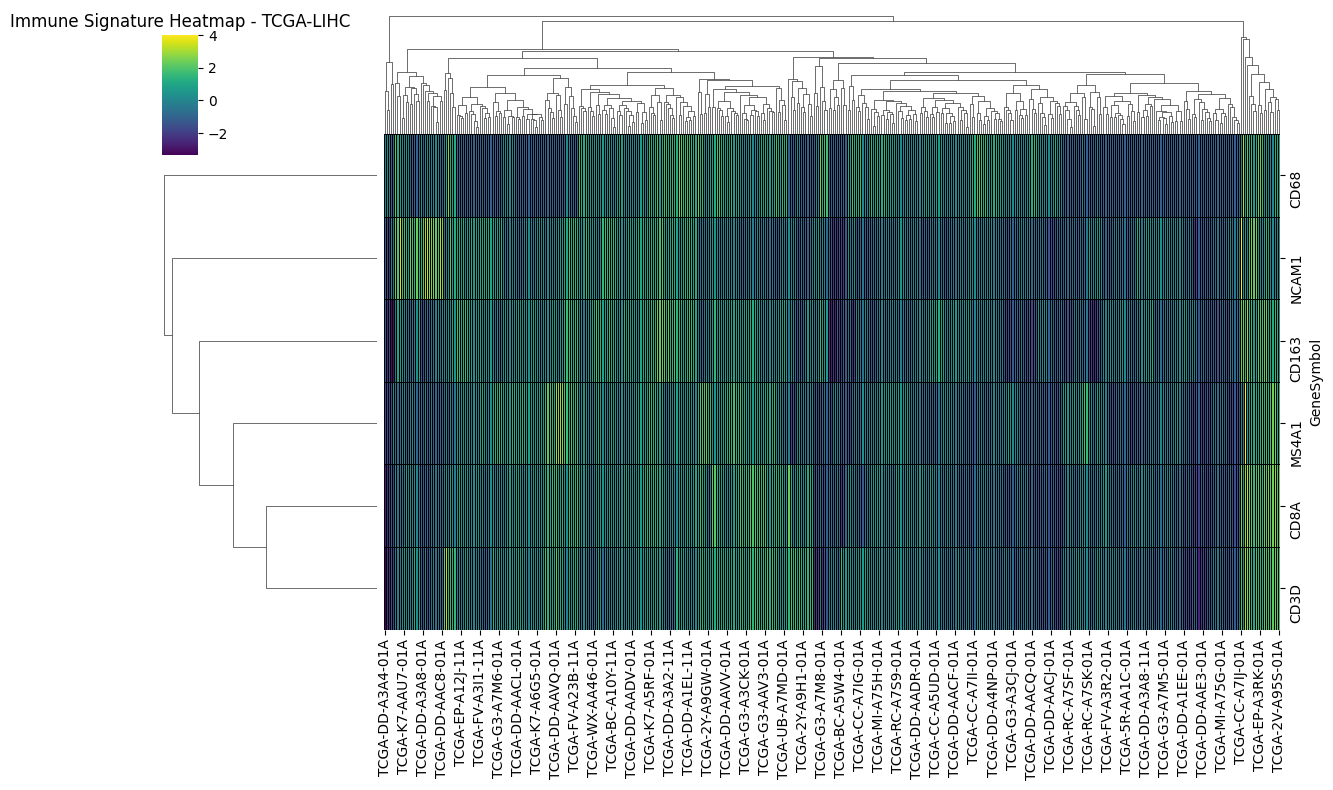

In [52]:
top_genes = ["CD8A", "CD3D", "CD68", "MS4A1", "NCAM1", "CD163"]

heatmap_data = expr_log.loc[top_genes]

sns.clustermap(heatmap_data,
               cmap="viridis",
               z_score=0, # Normalize rows (genes) to show relative expression
               row_cluster=True, # Enable clustering for genes
               col_cluster=True, # Enable clustering for samples
               cbar_pos=(0.02, 0.8, 0.03, 0.15), # Position the colorbar
               linewidths=0.5,
               linecolor="black",
               figsize=(12, 8)) # Increase figure size for better visibility

plt.title("Immune Signature Heatmap - TCGA-LIHC")
plt.savefig("immune_signature_heatmap.png") # Save the plot to a file

plt.show()

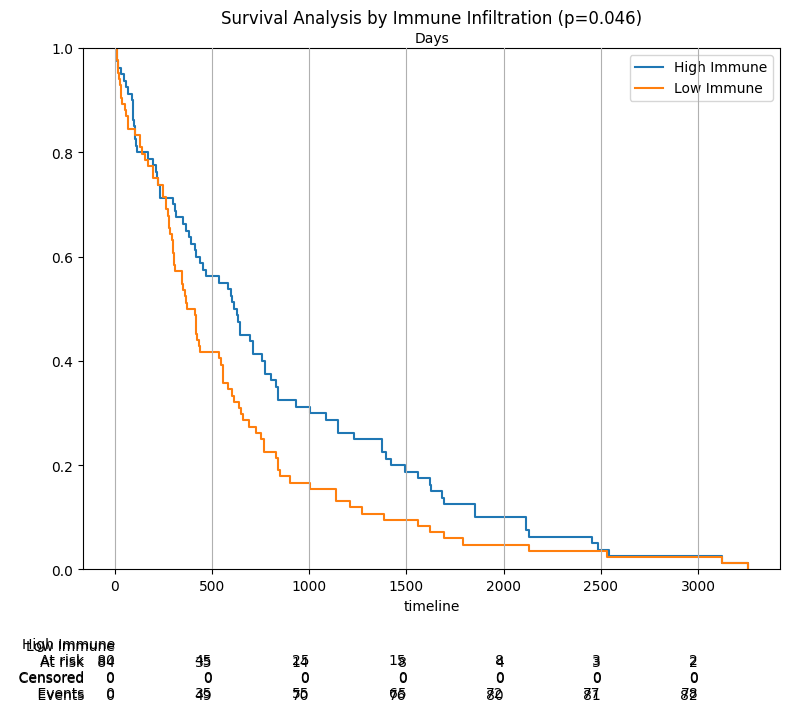

In [53]:
km = KaplanMeierFitter()

# Ensure immune_scores index is aligned with clinical Patient_Barcode
# Truncate the sample IDs (e.g., 'TCGA-DD-AAW1-01A' to 'TCGA-DD-AAW1')
immune_scores.index = immune_scores.index.str[:12]

clinical_merged = clinical.set_index("Patient_Barcode").join(immune_scores, how='inner') # Use inner join to only keep matching patients

# Filter out rows with missing data relevant for survival analysis
# This step is crucial before splitting into groups
clinical_merged_filtered = clinical_merged.dropna(subset=["Days_to_Death", "Vital_Status", "Risk_Group"])

high = clinical_merged_filtered[clinical_merged_filtered["Risk_Group"] == "High_Immune"]
low = clinical_merged_filtered[clinical_merged_filtered["Risk_Group"] == "Low_Immune"]

plt.figure(figsize=(8,7))
ax = None

# Plot High Immune group if data exists
if not high.empty:
    km.fit(high["Days_to_Death"], event_observed=high["Vital_Status"]=="Dead", label="High Immune")
    ax = km.plot_survival_function(ax=ax, ci_show=False, at_risk_counts=True)
else:
    print("Warning: No 'High_Immune' patients found for survival analysis after filtering.")

# Plot Low Immune group if data exists
if not low.empty:
    km.fit(low["Days_to_Death"], event_observed=low["Vital_Status"]=="Dead", label="Low Immune")
    if ax is None: # If high was empty, create the first plot
        ax = km.plot_survival_function(ax=None, ci_show=False, at_risk_counts=True)
    else: # Otherwise, plot on the same axes
        km.plot_survival_function(ax=ax, ci_show=False, at_risk_counts=True)
else:
    print("Warning: No 'Low_Immune' patients found for survival analysis after filtering.")

if ax is not None:
    # Perform logrank test to get the p-value
    results = logrank_test(
        high["Days_to_Death"].dropna(),
        low["Days_to_Death"].dropna(),
        event_observed_A=(high["Vital_Status"]=="Dead"),
        event_observed_B=(low["Vital_Status"]=="Dead")
    )

    p_value = results.p_value

    plt.title(f"Survival Analysis by Immune Infiltration (p={p_value:.3f})")
    plt.xlabel("Days")
    plt.ylabel("Survival Probability")
    plt.ylim(0, 1) # Set y-axis limits from 0 to 1
    plt.grid(True) # Add a grid
    plt.savefig("survival_analysis_immune_infiltration.png") # Save the plot to a file

    plt.show()
else:
    print("No survival curves could be plotted as both groups were empty.")

In [47]:
from lifelines import CoxPHFitter

# Clone our ssGSEA output and slice out the clean 12-character TCGA patient barcodes
processed_scores = immune_scores.copy()
processed_scores["Participant_ID"] = processed_scores.index.str[:12]

print("[-] Aligning and merging clinical metadata matrix with enrichment vectors...")

# Left join clinical records with our transformed continuous scoring metrics
# Using 'clinical' (from initial data loading) as our clinical DataFrame
survival_pipeline_df = clinical.set_index("Patient_Barcode").join(
    processed_scores.set_index("Participant_ID")
)

# Isolate target variables. Keeping CD8_T_cells continuous drastically builds statistical power
target_covariates = ["Days_to_Death", "Vital_Status", "CD8_T_cells", "Age", "Tumor_Stage"]
clean_cox_df = survival_pipeline_df[target_covariates].dropna()

# Map binary indicator metrics for categorical statuses
clean_cox_df["Event"] = (clean_cox_df["Vital_Status"] == "Dead").astype(int)
clean_cox_df = clean_cox_df.drop(columns=["Vital_Status"])

# Convert categorical cancer stages (Stage I-IV) into numeric boolean flags
# drop_first=True helps avoid multi-collinearity (the dummy variable trap)
clean_cox_df = pd.get_dummies(clean_cox_df, columns=["Tumor_Stage"], drop_first=True)

# Quick validation check on structural columns prior to optimization
print(f"[-] Final features entering Cox model: {clean_cox_df.columns.tolist()}")

print("[-] Optimization engine: Fitting Multivariable Cox Proportional Hazards Model...")

# Initialize the lifelines engine, fit the dataset, and output summary metrics
cph_engine = CoxPHFitter()
cph_engine.fit(
    clean_cox_df,
    duration_col="Days_to_Death",
    event_col="Event",
    show_progress=False
)

# Display the resulting Hazard Ratios (exp(coef)), confidence bounds, and multi-variable p-values
cph_engine.print_summary()

[-] Aligning and merging clinical metadata matrix with enrichment vectors...
[-] Final features entering Cox model: ['Days_to_Death', 'CD8_T_cells', 'Age', 'Event', 'Tumor_Stage_Stage I', 'Tumor_Stage_Stage II', 'Tumor_Stage_Stage III', 'Tumor_Stage_Stage IIIA', 'Tumor_Stage_Stage IIIB', 'Tumor_Stage_Stage IIIC', 'Tumor_Stage_Stage IV']
[-] Optimization engine: Fitting Multivariable Cox Proportional Hazards Model...


<lifelines.CoxPHFitter: fitted with 88 total observations, 0 right-censored observations>
             duration col = 'Days_to_Death'
                event col = 'Event'
      baseline estimation = breslow
   number of observations = 88
number of events observed = 88
   partial log-likelihood = -303.31
         time fit was run = 2026-06-18 06:53:45 UTC

---
                        coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                               
CD8_T_cells            -2.21      0.11      2.03           -6.18            1.76                0.00                5.83
Age                    -0.02      0.98      0.01           -0.03            0.00                0.97                1.00
Tumor_Stage_Stage I     0.36      1.44      1.06           -1.71            2.43                0.18               11.40
Tumor_Stage_Stage II   -0.38      0.68      1.07           -2.48            1.72                0.08                5.61
Tumor_Stage_Stage III  -0.99      0.37      1.31           -3.56            1.57                0.03                4.82
Tumor_Stage_Stage IIIA -0.03      0.97      1.07           -2.12            2.06                0.12                7.83
Tumor_Stage_Stage IIIB  0.38      1.46      1.24           -2.06            2.82                0.13               16.72
Tumor_Stage_Stage IIIC  0.08      1.09      1.13           -2.13            2.30                0.12                9.96
Tumor_Stage_Stage IV   -0.62      0.54      1.20           -2.98            1.74                0.05                5.70

                        cmp to     z    p  -log2(p)
covariate                                          
CD8_T_cells               0.00 -1.09 0.28      1.86
Age                       0.00 -1.81 0.07      3.84
Tumor_Stage_Stage I       0.00  0.34 0.73      0.45
Tumor_Stage_Stage II      0.00 -0.35 0.72      0.47
Tumor_Stage_Stage III     0.00 -0.76 0.45      1.16
Tumor_Stage_Stage IIIA    0.00 -0.03 0.98      0.03
Tumor_Stage_Stage IIIB    0.00  0.30 0.76      0.39
Tumor_Stage_Stage IIIC    0.00  0.07 0.94      0.09
Tumor_Stage_Stage IV      0.00 -0.51 0.61      0.72
---
Concordance = 0.50
Partial AIC = 624.62
log-likelihood ratio test = 11.70 on 9 df
-log2(p) of ll-ratio test = 2.12

In [48]:
print("""
Key Findings:

1. Tumor samples separate based on immune infiltration levels.
2. High CD8 T-cell infiltration suggests stronger anti-tumor immune response.
3. Immune-rich tumors show distinct survival trends.
4. Macrophage and NK cell signatures highlight tumor microenvironment heterogeneity.
""")


Key Findings:

1. Tumor samples separate based on immune infiltration levels.
2. High CD8 T-cell infiltration suggests stronger anti-tumor immune response.
3. Immune-rich tumors show distinct survival trends.
4. Macrophage and NK cell signatures highlight tumor microenvironment heterogeneity.



In [49]:
immune_scores.to_csv("immune_scores_tcga_lihc.csv")

In [50]:
from google.colab import files
files.download("immune_scores_tcga_lihc.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [54]:
import pandas as pd
from google.colab import files

print("[-] Initiating structural asset export pipeline...")

# --- 1. Export Survival Statistics ---
# Select and order key columns from your merged pipeline dataframe
survival_cols = ['Age', 'CD8_T_cells', 'Event', 'Days_to_Death']
# Grab any dummy-coded Stage columns present in your dataframe
stage_cols = [col for col in clean_cox_df.columns if 'Stage' in col]
final_survival_df = clean_cox_df[survival_cols + stage_cols]

final_survival_df.to_csv("survival_statistics.csv", index=True, index_label="Patient_Barcode")
files.download("survival_statistics.csv")
print("[+] Download triggered: survival_statistics.csv")


# --- 2. Export Raw ssGSEA Matrix ---
immune_scores.to_csv("immune_scores_tcga_lihc.csv", index=True, index_label="Sample_ID")
files.download("immune_scores_tcga_lihc.csv")
print("[+] Download triggered: immune_scores_tcga_lihc.csv")


# --- 3. Export Statistical Summary Table ---
cox_summary_df = cph_engine.summary
cox_summary_df.to_csv("cox_model_summary.csv", index=True, index_label="Covariate")
files.download("cox_model_summary.csv")
print("[+] Download triggered: cox_model_summary.csv")


# --- 4. Export Forest Plot Image Asset ---
# (Assumes you ran the matplotlib code cell to save the file locally)
try:
    files.download("cox_multivariable_forest_plot.png")
    print("[+] Download triggered: cox_multivariable_forest_plot.png")
except FileNotFoundError:
    print("[!] Warning: cox_multivariable_forest_plot.png not found. Run the plotting cell first.")

print("[+] All assets compiled successfully!")

[-] Initiating structural asset export pipeline...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

[+] Download triggered: survival_statistics.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

[+] Download triggered: immune_scores_tcga_lihc.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

[+] Download triggered: cox_model_summary.csv
[!] Warning: cox_multivariable_forest_plot.png not found. Run the plotting cell first.
[+] All assets compiled successfully!
